# Two-Level System

In this notebook, we will be building up the two-level RbQ simulation of absorbing an incoming coherent state. First, we consider a constant coupling between the atom and light, no dissipation. We show this matches with the expected calculation from the Schrodinger equation. Then, we include dissipation. Then, we include the derived optimal coupling pulse with dissipation to show that the stored information does not go to 0 when you optimize your control pulse.

I am considering interaction between an atom and 1D light field as outlined in RbQ Method Overleaf (freespace2level pdf). A single coherent beam interacting with a single atom has the Hamiltonian:

$$\hat{H} = g \hat{\textbf{a}}(t)\hat{\sigma}_+ + g^* \hat{\textbf{a}}^\dagger(t)\hat{\sigma}_-$$

- $g$ is the coupling betwen the light and atom.
- $\hat{\textbf{a}}(t)$ is a bath operator which is different at each point in time (?). This is defined as $\hat{\textbf{a}}(t)= \hat{a}_0(t) + \alpha(t) $, where $\hat{a}_0(t)$ is the vacuum annihilation operator. 

For simplicity, I am considering the case where the driving field (photon) is coherent ($\alpha$ and $g$ are both real) interacts with a two-level system (TLS). We also ignore the vacuum field, which is under the assumption that the $\alpha$ is much larger than vacuum. Eventually, we will have to account for vacuum since our $\alpha$ is small. This leads to:

$$\hat{H} = -g(t)\alpha(t) \hat{\sigma}_x$$

We will solve this time-dependent Hamiltonian (solved in Qutip found in https://qutip.org/docs/4.7/guide/dynamics/dynamics-time.html) and determine the expectation value of the atom's state, to see if the atom has "spun up" as expected.

In [2]:
import matplotlib.pyplot as plt
#plt.rcParams['text.usetex'] = False  # use mathtext renderer
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman']
#plt.rcParams['figure.dpi'] = 150  # higher resolution for figures

# To render as in Latex font
'''params = {
   'axes.labelsize': 18,
   'font.size': 18,
   'legend.fontsize': 18,
   'xtick.labelsize': 18,
   'ytick.labelsize': 18,
   'axes.titlesize': 18,
   'text.usetex': True,
   'font.family':'serif',
   'font.serif':'Computer Modern',
   'figure.dpi': 150
   }
plt.rcParams.update(params)
plt.rcParams["font.serif"] = "Computer Modern Roman"
plt.rcParams["font.family"] = "Serif"
'''

import qutip
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d

I am going to put code here as a reminder to Qutip notation: see Overleaf for more details.

In [3]:
up = basis(2, 0) # up state
print(up)
print(sigmam() * up) # if in the excited state, should end up in the ground state
print(sigmap() * up) # if in the excited state, we have raised the qubit state out of the truncated TLS Hilbert space, yielding [0; 0] 

down = basis(2, 1) # down state
print(down)
print(sigmam() * down) # if in the ground state, we have lowered the qubit state out of the truncated TLS Hilbert space, yielding [0; 0] 
print(sigmap() * down) # if in the ground state, should end up in the excited state

print(expect(sigmaz(), up)) # +1 for up spin
print(expect(sigmaz(), down)) # -1 for down spin

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
1.0
-1.0


First, we will assume the incoming wavepacket $\alpha(t)$ has a Gaussian profile. The average occupation number $N$ (number of photons) in the pulse $\alpha$ is given by $$N=\int_{-\infty}^\infty |\alpha(t)|^2 dt$$ 

So, the normalized expression for a pulse with $N=1$ is:

$$\alpha(t) = \sqrt{\frac{1}{\sigma\sqrt{\pi}}} e^{-(x-\mu)^2/2\sigma^2}$$

where $\mu$, $\sigma$ are the mean and standard deviation of the Gaussian, respectively. This expression describes the average energy of a single photon. A temporal mode is a member of a basis with energy equal to 1. 

I am currently assuming that the coupling strength $g$ is constant. 

In [4]:
### INPUT PARAMETERS
T = 10 # total time (input pulse "duration")
N = 2000 # number of time steps
time = np.linspace(0, T, N)

mu, sigma = 5/2, 5/10
# Returned area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-(t-mu)**2/(2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    a = 0.1 # small amplitude
    return a*(gaussian(mu, sigma, t)) # + np.random.normal(0, sigma*0.01, 1)) # Gaussian input
alpha = alpha_in(time)
print("Area of alpha:", integrate.simps(alpha**2, time))

### COUPLING PARAMETER
g = 1 # coupling strength between atom and light

Area of alpha: 0.009999999999992314


In [5]:
### HAMILTONIAN CONSTRUCTION
def H1_coeff_const_g(t, args): # Hamiltonian coefficient for constant g
    return g * alpha_in(t) 

H0 = Qobj([[0, 0], [0, 0]]) # time-independent part of Hamiltonian
H1 = Qobj([[0, 1], [1, 0]])
H = [H0,[H1, H1_coeff_const_g]] 

Here, we can see the coupling shape needed to maximally spin up kind of matches the math in the Gorshkov paper. This shape intuitively makes sense because you have a large increase in the coupling at the beginning to "record" as much of the incoming pulse as possible. 

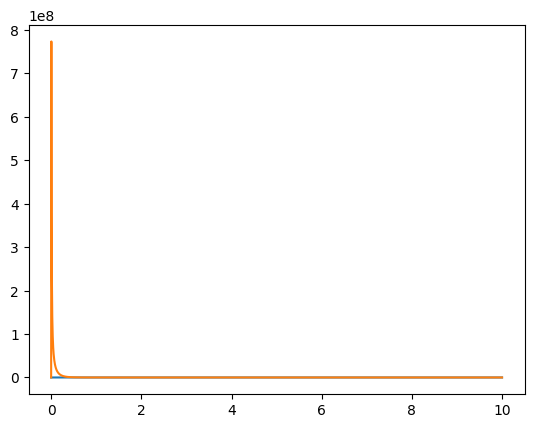

In [6]:
g_opt = []
for i in range(0, len(time)):
    if i == 0: g_test = 0
    else: g_test = (np.pi/2)/integrate.simps(alpha[0:i+1], time[0:i+1]) # coupling that "maximizes" overlap integral
    g_opt.append(g_test)
plt.plot(time, alpha, label=r'Input pulse α_in(t)')
plt.plot(time, g_opt, label=r'g(t)')
#plt.ylim([0, 10])

The spin value is defined as: $ S(t) = \langle \hat{\sigma}_- \rangle $ where $ \hat{\sigma}_- = | g \rangle \langle e |$. If we define an atom's state $\ket{\psi}= c_g\ket{g} + c_e\ket{e}$, this makes the expectation value $$\langle S \rangle = c_g^*c_e$$ 

We will use $S$ as a metric for how much of the incoming pulse is stored in the atom's excited state because we are considering weak signals, aka signals where the amplitude of the input pulse is small and therefore $c_g \sim 1$ at all times. We are trying to maximize the excited state probability $c_e$, which is equivalent in this limit to maximizing $S$.

Note that in the case outside of this limit, it is possible that even if the atom is excited/spun up all the way ($c_e=1$),  $S=0$ because $c_g = 0$.

In [7]:
# DISSIPATION OPERATORS (collapse operators)
c_op_list = []

### SIMULATE: starting from the ground state, solve Schrodinger equation (no dissipation) 
psi0 = basis(2, 1) # |g> (see above)
result = mesolve(H, psi0, time, c_op_list) 

# Verify the correct probability of ground/excited state indices
i=2
print(result.states[i])
print(result.states[i][0][0])
print(result.states[i][1][0])

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.-4.17941488e-09j]
 [1.+0.00000000e+00j]]
-4.179414881897069e-09j
(1+0j)


In [8]:
prob_ground = [] # probability of finding state in |g>
prob_excited = [] # probability of finding state in |e>
S_expect = [] # expectation value of lowering operator

for i in range(0, len(result.states)):
    p_g, p_e = result.states[i][1][0], result.states[i][0][0]
    S = expect(sigmam(), result.states[i])
    if S != p_g.conjugate()*p_e: print("Mismatch: ", S, p_e*p_g.conjugate())
    S_expect = np.append(S_expect, S)
    
    prob_ground = np.append(prob_ground, abs(p_g)**2)
    prob_excited = np.append(prob_excited, abs(p_e)**2)

print('Final S: ', abs(S_expect[-1]))
print("Max excited state population:", max(prob_excited))
print("Final excited state population:", prob_excited[-1])

Final S:  0.13156664753629446
Max excited state population: 0.01762025617148841
Final excited state population: 0.01762025617148841


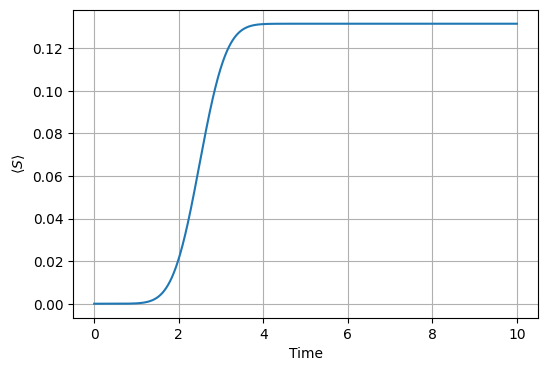

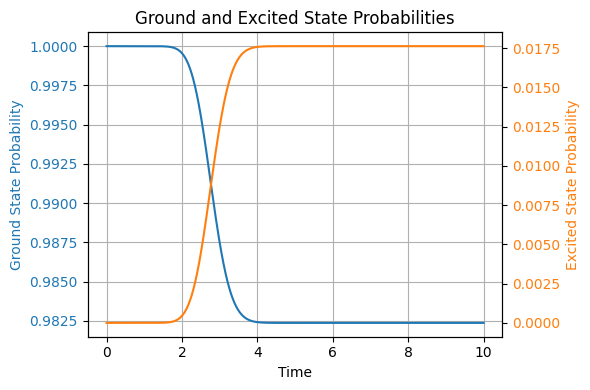

In [9]:
plt.figure(figsize=(6,4))
plt.plot(time, abs(S_expect))
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()

fig, ax1 = plt.subplots(figsize=(6, 4))
color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Ground State Probability', color=color)
ax1.plot(time, prob_ground, label='Ground State', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid()

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Excited State Probability', color=color)
ax2.plot(time, prob_excited, label='Excited State', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ground and Excited State Probabilities')
plt.tight_layout()
plt.show()

### Checking simulation analytically
We can check the results of this mesolve by calculating the time-evolution operator ourselves. From the pdf: $\hat{H}$ commutes with itself at different times so the expansion for the time evolution operator becomes (taking $\hbar$ to be $1$):

$$
U(t) = e^{-i\hat{H}t} = e^{i\hat{\sigma}_x \int_0^t g(\tau)\alpha(\tau)d\tau}
$$

From Wikipedia on Pauli matrix exponentials, we define and have:

$$
\Theta(t) = \int_0^t g(\tau) \alpha(\tau) d\tau
$$
which is the overlap integral, and

$$
U(t) = \cos(\Theta(t)) \hat{I} + i \sin(\Theta(t)) \hat{\sigma}_x
$$

We can then write $\ket{\psi(t)} = U(t) \ket{\psi_0}$.

We have two cases that we should check:

- Case 1: If the template is orthogonal to the incoming wavepacket, aka $g(t)$ orthogonal to $\alpha(t)$, the atom's state should not change.

$$ \int_0^t g(\tau)\alpha(\tau) d \tau=0 \rightarrow U(t)=\hat{I} $$

- Case 2: If the template perfectly matches the incoming wavepacket, aka $g(t)$ matches $\alpha(t)$ in some way, the atom's state should become excited. 

$$ \int_0^t g(\tau)\alpha(\tau) d \tau= \frac{\pi}{2} \rightarrow U(t)=i\hat{\sigma}_x $$

Note: $g$ is still constant here. 

In [10]:
Theta = np.array([])
prob_ground = []
prob_excited = []
psi_current = np.array([0, 1])  # initial state |g>
S = []

for i in range(0, len(time)):
    # Case 2: Let g be some constant that magically cancels out the integral of alpha. 
    #if i == 0: g = 0
    #else: g = (np.pi/2) / integrate.simps(alpha[0:i+1], time[0:i+1]) 

    integral_value, _ = integrate.quad(lambda x: g * alpha_in(x), 0, time[i])
    Theta = np.append(Theta, integral_value)

    U_matrix = np.cos(integral_value)*np.eye(2) + 1j*np.sin(integral_value) * np.array([[0, 1], [1, 0]])
    #U_matrix = np.eye(2) # Expected result of Case 1
    #U_matrix = 1j*np.array([[0, 1], [1, 0]]) # Expected result of Case 2

    p_e, p_g = (U_matrix @ psi_current)[0], (U_matrix @ psi_current)[1]
    S = np.append(S, p_g.conjugate()*p_e)

    prob_ground = np.append(prob_ground, (np.linalg.norm((U_matrix @ psi_current)[1]))**2)
    prob_excited = np.append(prob_excited, (np.linalg.norm((U_matrix @ psi_current)[0]))**2)

print('Final S: ', abs(S_expect[-1]))
print("Max excited state population:", max(prob_excited))
print("Final excited state population:", prob_excited[-1])

Final S:  0.13156664753629446
Max excited state population: 0.017620055880230648
Final excited state population: 0.017620055880220885


Yes, matches with previous simulation!

Max excited state population: 0.017620055880230648


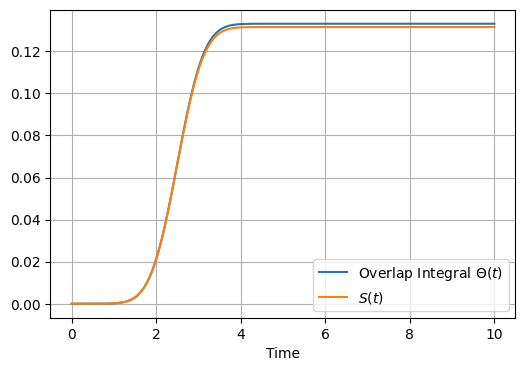

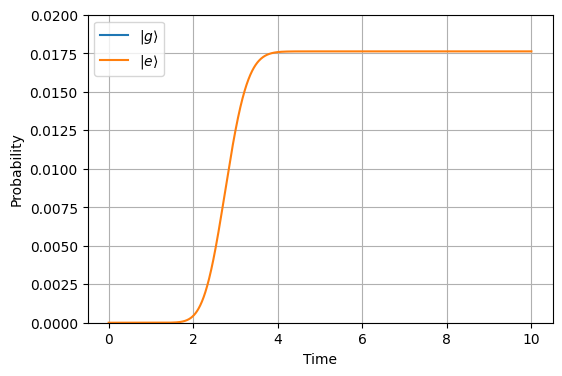

In [11]:
plt.figure(figsize=(6,4))
plt.plot(time, (Theta), label=r'Overlap Integral $\Theta(t)$')
plt.plot(time, abs(S), label=r'$S(t)$')
plt.xlabel('Time'); plt.legend(); plt.grid()

plt.figure(figsize=(6,4))
plt.plot(time, prob_ground, label=r'$|g\rangle$')
plt.plot(time, prob_excited, label=r'$|e\rangle$')
plt.xlabel('Time'); plt.ylabel('Probability'); plt.grid()
plt.ylim([0, 0.02])

plt.legend()
print("Max excited state population:", max(prob_excited))

## Adding in decay terms

Currently, we do not account for the atom spontaneously decaying (e to g). For a given bath mode, the Lindblad collapse operators are given by $$L= -g^*\hat{\sigma}_- $$ where $g$ is a function of time and $\hat{\sigma}_-$ is the lowering operator on the TLS ($\ket{g}\bra{e}$). For now, we will continue to assume $g$ is constant.

In [12]:
# DISSIPATION OPERATORES (collapse operators)
g=1
c_op_list = [-np.conjugate(g)*sigmam()] # Lindblad dissipation (collapse) operators

### SIMULATE: starting from the ground state, solve Schrodinger equation (with dissipation) 
psi0 = basis(2, 1) 
result = mesolve(H, psi0, time, c_op_list) 

prob_ground = [] # probability of finding state in |g>
prob_excited = [] # probability of finding state in |e>
S_expect = [] # expectation value of lowering operator

for i in range(0, len(result.states)):
    p_g, p_e = result.states[i][1][1], result.states[i][0][0]
    if np.imag(p_g) != 0 or np.imag(p_e) != 0:
        print("Imaginary part detected: ", p_g, p_e)
    S = expect(sigmam(), result.states[i])
    S_expect = np.append(S_expect, S)
    
    prob_ground = np.append(prob_ground, p_g)
    prob_excited = np.append(prob_excited, p_e)

As expected, the presence of decay causes the excited state population to decay down over time (averaged), so we no longer maintain that excited state.

Max excited state population: (0.007146996269531725+0j)


C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.0, 0.02)

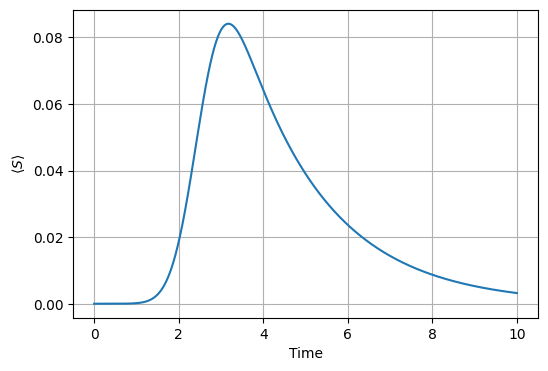

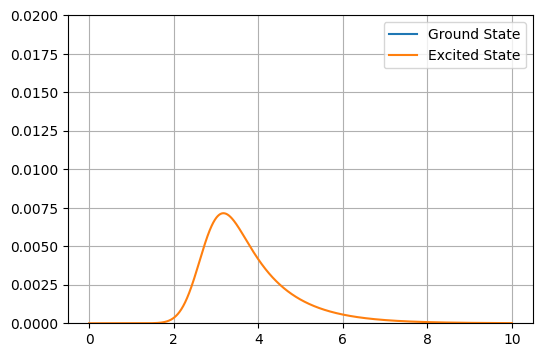

In [13]:
plt.figure(figsize=(6,4))
plt.plot(time, abs(S_expect))
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()

plt.figure(figsize=(6,4))
plt.plot(time, prob_ground, label='Ground State')
plt.plot(time, prob_excited, label='Excited State')
#plt.plot(time, alpha, label='Input coherent state')
#plt.plot(time, abs(S_expect)**2) # Matches with the excited state population
plt.legend(); plt.grid()
print("Max excited state population:", max(prob_excited))
plt.ylim([0, 0.02])

### Include optimal g 

We want to find the optimal shaped write pulse $g(t)$ (aka the ideal coupling) that maximizes excited state probability (the amount of excited state absorbed from the coherent state) with decay. We don't want to change $\alpha(t)$ since we want to accommodate an arbitrary temporal mode. From Eq. 56 in the freespace2level pdf, we have 

$$
g^*(t) = \frac{k_{||}(t)}{\sqrt{\int_{-\infty}^t |k_{||}(t)|^2dt}}
$$

where $k_{||}(t)$ is the normalized template ($ \int_{-\infty}^\infty|k(t)^2|dt = 1$) that overlaps with the incoming signal. This is similar to Gorshkov but without the phase term because we have a TLS, not three-level system. We will set this to be the same shape as $\alpha_{in}$ (Gaussian) since that would be a perfect overlap. 

Area of template k(t): 0.9999999999992311


(0.0, 11.0)

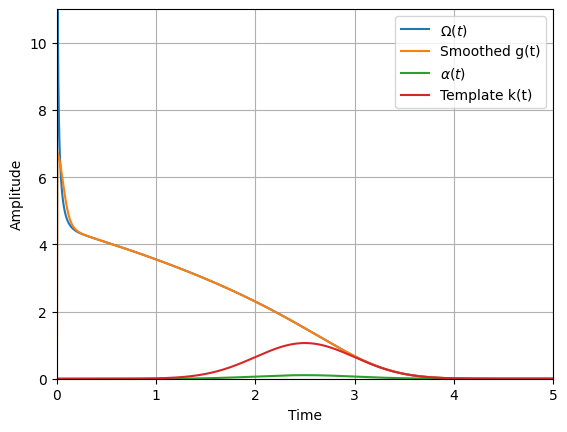

In [14]:
### TEMPLATE FUNCTION (k(t) = template at time t)
def k(t):
    return gaussian(mu, sigma, t) # for matched template
    #return gaussian(mu, sigma, t) * np.sin(t-mu)

### COUPLING FUNCTION (g(t) = coupling strength between atom and light at time t)
def g(t):
    integral_value, _ = integrate.quad(lambda x: np.abs(k(x))**2, 0, t) # Denominator -inf to t
    return k(t) / np.sqrt(integral_value) if integral_value > 0 else 0

g_vals, k_vals = [], []
for t in time: 
    g_vals.append(g(t)) 
    k_vals.append(k(t))

print("Area of template k(t):", integrate.simps(np.array(k_vals)**2, time))

g_vals_smoothed = gaussian_filter1d(g_vals, sigma=10)  # Apply Gaussian smoothing
def g_smoothed(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, g_vals_smoothed)  # Interpolate smoothed g values

plt.plot(time, g_vals, label=r'$\Omega(t)$')
plt.plot(time, [g_smoothed(t) for t in time], label='Smoothed g(t)')  # Plot smoothed g(t)
plt.plot(time, [alpha_in(t) for t in time], label=r'$\alpha(t)$')
plt.plot(time, k_vals, label='Template k(t)')
plt.legend(); plt.grid(); plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.xlim([0, 5]); plt.ylim([0, 11])

In [15]:
### HAMILTONIAN
H0 = Qobj([[0, 0], [0, 0]]) # time-independent part of Hamiltonian
H1 = Qobj([[0, 1], [1, 0]])  
def H1_coeff(t, args): 
    return g_smoothed(t) * alpha_in(t) 
H = [H0,[H1, H1_coeff]] # Final Hamiltonian

# DISSIPATION OPERATORES (collapse operators)
def col_coeff(t, args):  # coefficient function
    return -np.conjugate(g_smoothed(t))
c_op_list = [[sigmam(), col_coeff]]  # time-dependent collapse term
# H[1][1](t, None) = H1_coeff at time t

Final S:  0.09900357963050957
Max excited state population: (0.009933488130028036+0j)
Final excited state population: (0.009933488121508155+0j)


(0.0, 0.02)

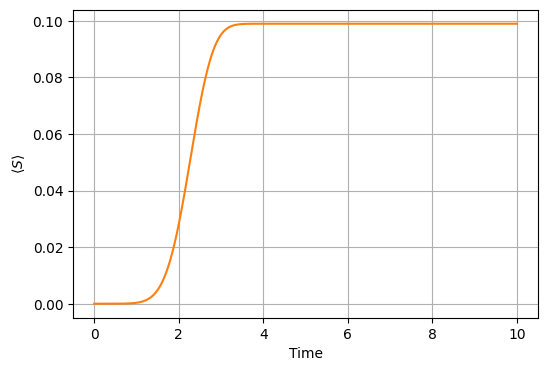

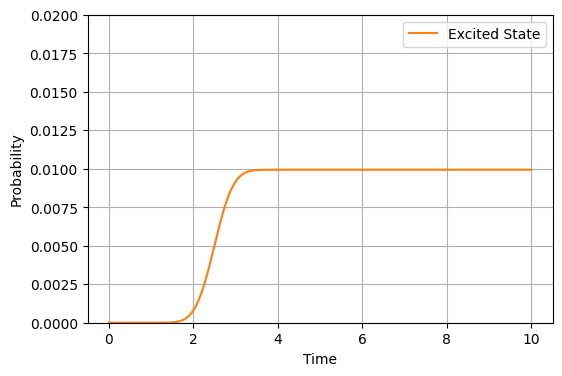

In [16]:
### SIMULATE: starting from the ground state, solve Schrodinger equation
psi0 = basis(2, 1) # |g> in the sigma z basis = [1, 0]'
result = mesolve(H, psi0, time, c_op_list) 

prob_ground = [] # probability of finding state in |g>
prob_excited = [] # probability of finding state in |e>
S_expect = [] # expectation value of lowering operator
for i in range(0, len(result.states)):
    # If you want to test the case without dissipation (c_op_list = []), the output is in state vector format
    #p_g, p_e = result.states[i][1][0], result.states[i][0][0] 

    p_g, p_e = result.states[i][1][1], result.states[i][0][0]    
    prob_ground = np.append(prob_ground, p_g)
    prob_excited = np.append(prob_excited, p_e)
    S_expect = np.append(S_expect, expect(sigmam(), result.states[i]))

print('Final S: ', abs(S_expect[-1]))
print("Max excited state population:", max(prob_excited))
print("Final excited state population:", prob_excited[-1])

plt.figure(figsize=(6,4))
plt.plot(time, abs(S_expect), color='tab:orange')
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()

plt.figure(figsize=(6,4))
#plt.plot(time, prob_ground, label='Ground State')
plt.plot(time, prob_excited, label='Excited State', color='tab:orange')
#plt.plot(time, alpha, label='Input coherent state')
plt.legend(); plt.grid(); plt.xlabel('Time')
plt.ylabel('Probability')
plt.ylim([0, 0.02])

We can confirm the validity of our spin curve because from RbQ Method, we expect:

$$S^2 = \int_0^t {\alpha^2_{in}(t)dt}$$

0.09999999999996156
0.09900357963050957


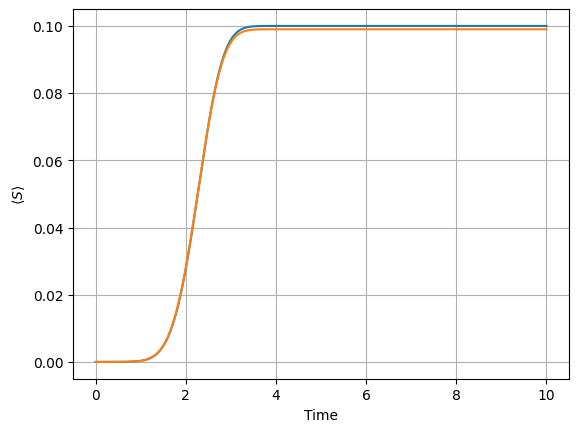

In [17]:
S_squared = []
for i in range(0, len(time)):
    if i == 0: S_squared.append(0)
    else:      S_squared.append(integrate.simps(abs(alpha[0:i])**2, time[0:i]))

plt.plot(time, np.sqrt(S_squared), label='Analytical S')
plt.plot(time, abs(S_expect), label='Simulated S')
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()

print(np.sqrt(S_squared[-1]))
print(abs(S_expect[-1]))

A few notes:
- The two curves of S do not perfectly overlap, but this is likely due to our smoothing of the $g(t)$ function and the finite time steps we take in the simulation. As we increase the number of time steps, the curves get closer together. 
- The expectation value of S (and also the excited state probability) converge to $\sim 0.01$, which makes sense as the area $\int |\alpha|^2 dt$ is 0.01 so we expect to measure a photon with probability 0.01 (corresponding to the average number of photons in a given pulse/signal). 
- Note: $S = c_g^* c_e$ where $c_e$ is a square root of probability. This is why S converges to 0.1, not 0.01. 


### Orthogonal template case

Recall that in the section "Checking simulation analytically," if the template is orthogonal to the signal then it satisfies $ \int_0^t g(\tau)\alpha(\tau) d \tau=0$, this is not relevant because you didn't account for decay, etc. So, to make $g(t)$ orthogonal, all we do is adjust $k(t)$ such that it satisfies $\int k(t) dt = 0$. Word of caution: $k(t)$ must be odd around $\mu$ so that $g(t)$ overlaps properly with $\alpha(t)$.

As long as the orthogonal template integrates to zero over the time you are simulating for, should be fine? If not, you should get some nonzero S.

- How do I prove that g(t) and alpha are orthogonal by changing k(t)?
- Why is the integral of g(t)alpha(t) not going to 0? It is not going to 0 because I have not accounted for the decay. 

In [18]:
'''# Normalization factor for orthogonal template k(t) (such that int(|k(t)|^2) = 1)
factor = np.sqrt(integrate.simps((gaussian(mu, sigma, time) * np.sin(time-mu))**2, time))

### TEMPLATE FUNCTION (k(t) = template at time t)
def k(t):
    return gaussian(mu, sigma, t) * np.sin(t-mu) / factor # for ORTHOGONAL TEMPLATE (unnormalized))

### COUPLING FUNCTION (g(t) = coupling strength between atom and light at time t)
def g(t):
    integral_value, _ = integrate.quad(lambda x: np.abs(k(x))**2, 0, t) # Denominator -inf to t
    return k(t) / np.sqrt(integral_value) if integral_value > 0 else 0

g_vals, k_vals = [], []
for t in time: 
    g_vals.append(g(t)) 
    k_vals.append(k(t))

print("Area of template k(t):", integrate.simps(np.array(k_vals)**2, time))

g_vals_smoothed = gaussian_filter1d(g_vals, sigma=10)  # Apply Gaussian smoothing
def g_smoothed(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, g_vals_smoothed)  # Interpolate smoothed g values

#plt.plot(time, g_vals, label=r'$g(t)$')
#plt.plot(time, [g_smoothed(t) for t in time], label='Smoothed g(t)')  # Plot smoothed g(t)
plt.plot(time, [alpha_in(t) for t in time], label=r'$\alpha(t)$')
plt.plot(time, k_vals, label='Template k(t)')
plt.plot(time, g_vals*alpha, label=r'$g(t)\alpha(t)$')

print(r'Integral of $g(t)\alpha(t)$ over time array: ', integrate.simps(alpha*g_vals, time))

plt.legend(); plt.grid(); plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.xlim([0, 5]); '''

'# Normalization factor for orthogonal template k(t) (such that int(|k(t)|^2) = 1)\nfactor = np.sqrt(integrate.simps((gaussian(mu, sigma, time) * np.sin(time-mu))**2, time))\n\n### TEMPLATE FUNCTION (k(t) = template at time t)\ndef k(t):\n    return gaussian(mu, sigma, t) * np.sin(t-mu) / factor # for ORTHOGONAL TEMPLATE (unnormalized))\n\n### COUPLING FUNCTION (g(t) = coupling strength between atom and light at time t)\ndef g(t):\n    integral_value, _ = integrate.quad(lambda x: np.abs(k(x))**2, 0, t) # Denominator -inf to t\n    return k(t) / np.sqrt(integral_value) if integral_value > 0 else 0\n\ng_vals, k_vals = [], []\nfor t in time: \n    g_vals.append(g(t)) \n    k_vals.append(k(t))\n\nprint("Area of template k(t):", integrate.simps(np.array(k_vals)**2, time))\n\ng_vals_smoothed = gaussian_filter1d(g_vals, sigma=10)  # Apply Gaussian smoothing\ndef g_smoothed(t):\n    if t == time[0]: return 0\n    else:            return np.interp(t, time, g_vals_smoothed)  # Interpolate smooth

In [19]:
'''### HAMILTONIAN
def H1_coeff(t, args): 
    return g_smoothed(t) * alpha_in(t) 
H = [H0,[H1, H1_coeff]] # Final Hamiltonian

# DISSIPATION OPERATORES (collapse operators)
def col_coeff(t, args):  # coefficient function
    return -np.conjugate(g_smoothed(t))
c_op_list = [[sigmam(), col_coeff]]  # time-dependent collapse term'''

'### HAMILTONIAN\ndef H1_coeff(t, args): \n    return g_smoothed(t) * alpha_in(t) \nH = [H0,[H1, H1_coeff]] # Final Hamiltonian\n\n# DISSIPATION OPERATORES (collapse operators)\ndef col_coeff(t, args):  # coefficient function\n    return -np.conjugate(g_smoothed(t))\nc_op_list = [[sigmam(), col_coeff]]  # time-dependent collapse term'

In [20]:
'''### SIMULATE: starting from the ground state, solve Schrodinger equation
psi0 = basis(2, 1) # |g> in the sigma z basis = [1, 0]'
result = mesolve(H, psi0, time, c_op_list) 

prob_ground = [] # probability of finding state in |g>
prob_excited = [] # probability of finding state in |e>
S_expect = [] # expectation value of lowering operator
for i in range(0, len(result.states)):
    p_g, p_e = result.states[i][1][1], result.states[i][0][0] 
    prob_ground = np.append(prob_ground, p_g)
    prob_excited = np.append(prob_excited, p_e)

    S_expect = np.append(S_expect, expect(sigmam(), result.states[i]))

print('Final S: ', abs(S_expect[-1]))
print("Max excited state population:", max(prob_excited))
print("Final excited state population:", prob_excited[-1])

plt.figure(figsize=(6,4))
plt.plot(time, abs(S_expect), color='tab:orange', label='Sim S')
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()

plt.figure(figsize=(6,4))
plt.plot(time, prob_ground, label='Ground State')
plt.plot(time, prob_excited, label='Excited State', color='tab:orange')
#plt.plot(time, alpha, label='Input coherent state')
plt.legend(); plt.grid(); plt.xlabel('Time')
plt.ylabel('Probability')
plt.ylim([0, 0.02])'''

'### SIMULATE: starting from the ground state, solve Schrodinger equation\npsi0 = basis(2, 1) # |g> in the sigma z basis = [1, 0]\'\nresult = mesolve(H, psi0, time, c_op_list) \n\nprob_ground = [] # probability of finding state in |g>\nprob_excited = [] # probability of finding state in |e>\nS_expect = [] # expectation value of lowering operator\nfor i in range(0, len(result.states)):\n    p_g, p_e = result.states[i][1][1], result.states[i][0][0] \n    prob_ground = np.append(prob_ground, p_g)\n    prob_excited = np.append(prob_excited, p_e)\n\n    S_expect = np.append(S_expect, expect(sigmam(), result.states[i]))\n\nprint(\'Final S: \', abs(S_expect[-1]))\nprint("Max excited state population:", max(prob_excited))\nprint("Final excited state population:", prob_excited[-1])\n\nplt.figure(figsize=(6,4))\nplt.plot(time, abs(S_expect), color=\'tab:orange\', label=\'Sim S\')\nplt.ylabel(r\'$\\langle S \rangle$\'); plt.xlabel(\'Time\'); plt.grid()\n\nplt.figure(figsize=(6,4))\nplt.plot(time,

The excited state population and S increase slightly before decaying back down to 0, which intuitively makes sense as there is a point at which there is some maximal overlap in the two templates, but ultimatel there is no match between the two. One question that would be good to address is how "orthogonal" can the templates be, i.e. quantifying the rejection in some way. 

### Applying the read pulse

What if we want to see what temporal mode we get out? We apply a read pulse, which will essentially be the time reversed $g$, that outputs the matched temporal mode.

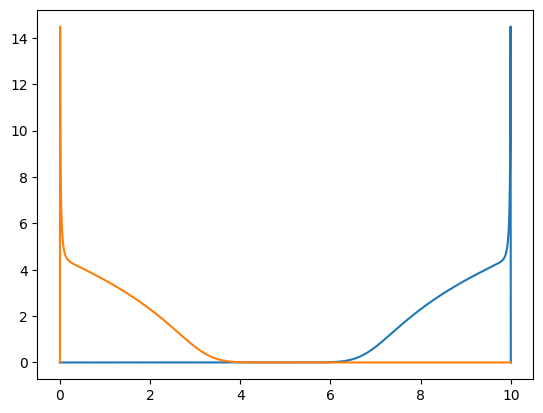

In [21]:
def g_read(t):
    return g(time[-1] - t)

g_read_vals = []
g_vals = []
for t in time: 
    g_read_vals.append(g_read(t)) 
    g_vals.append(g(t))

plt.plot(time, g_read_vals)
plt.plot(time, g_vals)

In [22]:
g_read_vals_smoothed = gaussian_filter1d(g_read_vals, sigma=10)  # Apply Gaussian smoothing
def g_read_smoothed(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, g_read_vals_smoothed)  # Interpolate smoothed g values

def H1_coeff(t, args): 
    return g_read_smoothed(t) * alpha_in(t) 
H = [H0,[H1, H1_coeff]] # Final Hamiltonian

# DISSIPATION OPERATORS (collapse operators)
def col_coeff(t, args):  # coefficient function
    return -np.conjugate(g_read_smoothed(t))
c_op_list = [[sigmam(), col_coeff]]  # time-dependent collapse term

In [ ]:
### SIMULATE: starting from the stored state, solve Schrodinger equation
# Start with the atom in the state we left it in in the previous simulation section
# It is in some mixed state (density matrix)
psi0 = result.states[-1]
result_read = mesolve(H, psi0, time, c_op_list) 

In [ ]:
result.states[-1]

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.00993349+0.j         0.        -0.09900358j]
 [0.        +0.09900358j 0.99006651+0.j        ]]

Final S:  3.283907334014566e-08
Max excited state population: (0.0099334881218393+0j)
Final excited state population: (1.3026437123790612e-08+0j)


(0.0, 0.02)

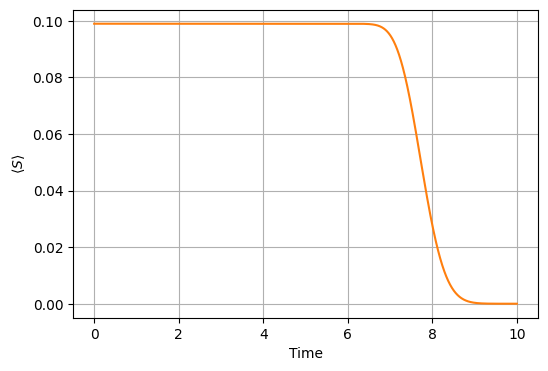

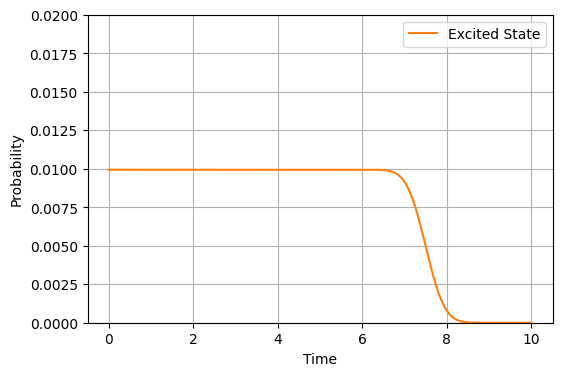

In [24]:
prob_ground = [] # probability of finding state in |g>
prob_excited = [] # probability of finding state in |e>
S_expect = [] # expectation value of lowering operator
for i in range(0, len(result_read.states)):
    p_g, p_e = result_read.states[i][1][1], result_read.states[i][0][0]    
    prob_ground = np.append(prob_ground, p_g)
    prob_excited = np.append(prob_excited, p_e)
    S_expect = np.append(S_expect, expect(sigmam(), result_read.states[i]))

print('Final S: ', abs(S_expect[-1]))
print("Max excited state population:", max(prob_excited))
print("Final excited state population:", prob_excited[-1])

plt.figure(figsize=(6,4))
plt.plot(time, abs(S_expect), color='tab:orange')
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()

plt.figure(figsize=(6,4))
#plt.plot(time, prob_ground, label='Ground State')
plt.plot(time, prob_excited, label='Excited State', color='tab:orange')
#plt.plot(time, alpha, label='Input coherent state')
plt.legend(); plt.grid(); plt.xlabel('Time')
plt.ylabel('Probability')
plt.ylim([0, 0.02])

In [25]:
print(np.conjugate(g_read_vals))
print(S_expect)

[1.47264584e-49 1.71101312e-49 1.98776432e-49 ... 1.05002182e+01
 1.44932012e+01 0.00000000e+00]
[0.-9.90035796e-02j 0.-9.90035796e-02j 0.-9.90035796e-02j ...
 0.-4.11310799e-08j 0.-3.67616589e-08j 0.-3.28390733e-08j]


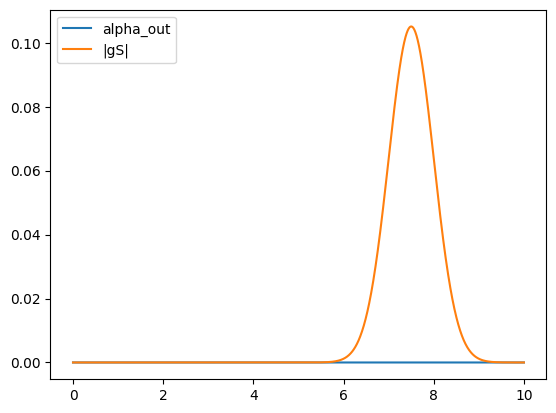

In [26]:
# Compute alpha_out
alpha_out = 0 - np.conjugate(g_read_vals)*S_expect
plt.plot(time, alpha_out, label='alpha_out')
#plt.plot(time, np.conjugate(g_read_vals)*S_expect, label='g* S')
plt.plot(time, np.abs(g_read_vals) * np.abs(S_expect), label='|gS|')
plt.legend()

In [ ]:
print('Compare photon number of alpha_out and alpha_in:')
print('alpha_out: ', integrate.simps((np.abs(g_read_vals) * np.abs(S_expect))**2, time))
print('alpha_in: ', integrate.simps(alpha**2, time))

Compare photon number of the output pulse and the template match:
0.009792097735728872
0.009999999999992314
